# Notebook: Non-Linear Least squares fitting, the basics

![](pictures/logo300px.png)

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Introduction" data-toc-modified-id="Introduction-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Introduction</a></span><ul class="toc-item"><li><span><a href="#Books:" data-toc-modified-id="Books:-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Books:</a></span></li><li><span><a href="#Preparing-the-environment" data-toc-modified-id="Preparing-the-environment-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Preparing the environment</a></span></li><li><span><a href="#Linear-models" data-toc-modified-id="Linear-models-1.3"><span class="toc-item-num">1.3&nbsp;&nbsp;</span>Linear models</a></span></li><li><span><a href="#Non-linear-models" data-toc-modified-id="Non-linear-models-1.4"><span class="toc-item-num">1.4&nbsp;&nbsp;</span>Non-linear models</a></span></li></ul></li><li><span><a href="#Linear-versus-Non-Linear-models" data-toc-modified-id="Linear-versus-Non-Linear-models-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Linear versus Non-Linear models</a></span></li><li><span><a href="#What-do-NLLS-routines-minimize?" data-toc-modified-id="What-do-NLLS-routines-minimize?-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>What do NLLS routines minimize?</a></span><ul class="toc-item"><li><span><a href="#How-to-implement-a-Least-Squares-fit?" data-toc-modified-id="How-to-implement-a-Least-Squares-fit?-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>How to implement a Least Squares fit?</a></span></li><li><span><a href="#Brute-force-method-to-find-the-minimum" data-toc-modified-id="Brute-force-method-to-find-the-minimum-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Brute force method to find the minimum</a></span></li></ul></li><li><span><a href="#Gradient-Descent" data-toc-modified-id="Gradient-Descent-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Gradient Descent</a></span><ul class="toc-item"><li><span><a href="#Definition" data-toc-modified-id="Definition-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Definition</a></span></li><li><span><a href="#Gradient-descent-for-univariate-model-e.g.-$f(x;\hat{\beta})-=-\beta_0-+-\beta_1-x$" data-toc-modified-id="Gradient-descent-for-univariate-model-e.g.-$f(x;\hat{\beta})-=-\beta_0-+-\beta_1-x$-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Gradient descent for univariate model e.g. $f(x;\hat{\beta}) = \beta_0 + \beta_1 x$</a></span></li></ul></li><li><span><a href="#Simple-fitting-with-scipy.optimize.curve_fit" data-toc-modified-id="Simple-fitting-with-scipy.optimize.curve_fit-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Simple fitting with <code>scipy.optimize.curve_fit</code></a></span></li><li><span><a href="#How-to-get-the-standard-errors-on-the-fitted-parameters-from-curve_fit()" data-toc-modified-id="How-to-get-the-standard-errors-on-the-fitted-parameters-from-curve_fit()-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>How to get the standard errors on the fitted parameters from <code>curve_fit()</code></a></span><ul class="toc-item"><li><span><a href="#A-non-linear-model" data-toc-modified-id="A-non-linear-model-6.1"><span class="toc-item-num">6.1&nbsp;&nbsp;</span>A non linear model</a></span><ul class="toc-item"><li><span><a href="#Can-I-also-use-a-variable-argument-list-for-the-definition-of-my-model?" data-toc-modified-id="Can-I-also-use-a-variable-argument-list-for-the-definition-of-my-model?-6.1.1"><span class="toc-item-num">6.1.1&nbsp;&nbsp;</span>Can I also use a variable argument list for the definition of my model?</a></span></li></ul></li><li><span><a href="#Calculation-of-the-reduced-Chi-squared" data-toc-modified-id="Calculation-of-the-reduced-Chi-squared-6.2"><span class="toc-item-num">6.2&nbsp;&nbsp;</span>Calculation of the reduced Chi squared</a></span></li><li><span><a href="#Curve_fit()-with-weigths" data-toc-modified-id="Curve_fit()-with-weigths-6.3"><span class="toc-item-num">6.3&nbsp;&nbsp;</span><code>Curve_fit()</code> with weigths</a></span></li><li><span><a href="#Unscaled-standard-errors" data-toc-modified-id="Unscaled-standard-errors-6.4"><span class="toc-item-num">6.4&nbsp;&nbsp;</span>Unscaled standard errors</a></span></li><li><span><a href="#Calculation-of-reduced-Chi-squared-for-fit-with-weighted-data" data-toc-modified-id="Calculation-of-reduced-Chi-squared-for-fit-with-weighted-data-6.5"><span class="toc-item-num">6.5&nbsp;&nbsp;</span>Calculation of reduced Chi squared for fit with weighted data</a></span></li><li><span><a href="#Disadvantages-of-function-curve_fit()" data-toc-modified-id="Disadvantages-of-function-curve_fit()-6.6"><span class="toc-item-num">6.6&nbsp;&nbsp;</span>Disadvantages of function <code>curve_fit()</code></a></span></li></ul></li><li><span><a href="#Fitting-with-SciPy's-LEASTSQ" data-toc-modified-id="Fitting-with-SciPy's-LEASTSQ-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Fitting with SciPy's LEASTSQ</a></span><ul class="toc-item"><li><span><a href="#The-objective-function" data-toc-modified-id="The-objective-function-7.1"><span class="toc-item-num">7.1&nbsp;&nbsp;</span>The objective function</a></span></li><li><span><a href="#Define-a-residuals-function-for-leastsq()" data-toc-modified-id="Define-a-residuals-function-for-leastsq()-7.2"><span class="toc-item-num">7.2&nbsp;&nbsp;</span>Define a residuals function for <code>leastsq()</code></a></span></li><li><span><a href="#Robust-fitting-with-leastsq()" data-toc-modified-id="Robust-fitting-with-leastsq()-7.3"><span class="toc-item-num">7.3&nbsp;&nbsp;</span>Robust fitting with <code>leastsq()</code></a></span><ul class="toc-item"><li><span><a href="#Robust-fitting,-another-example" data-toc-modified-id="Robust-fitting,-another-example-7.3.1"><span class="toc-item-num">7.3.1&nbsp;&nbsp;</span>Robust fitting, another example</a></span></li></ul></li><li><span><a href="#Orthogonal-fitting-with-leastsq" data-toc-modified-id="Orthogonal-fitting-with-leastsq-7.4"><span class="toc-item-num">7.4&nbsp;&nbsp;</span>Orthogonal fitting with <code>leastsq</code></a></span><ul class="toc-item"><li><span><a href="#Conclusion" data-toc-modified-id="Conclusion-7.4.1"><span class="toc-item-num">7.4.1&nbsp;&nbsp;</span>Conclusion</a></span></li></ul></li><li><span><a href="#leastsq():-Fitting-the-model-parameters-of-3-Gaussians-with-fixed-offset" data-toc-modified-id="leastsq():-Fitting-the-model-parameters-of-3-Gaussians-with-fixed-offset-7.5"><span class="toc-item-num">7.5&nbsp;&nbsp;</span><code>leastsq()</code>: Fitting the model parameters of 3 Gaussians with fixed offset</a></span></li></ul></li><li><span><a href="#(OPTIONAL)-KMPFIT" data-toc-modified-id="(OPTIONAL)-KMPFIT-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>(OPTIONAL) KMPFIT</a></span><ul class="toc-item"><li><span><a href="#Initialize-the-fitter-routine-in-kmpfit" data-toc-modified-id="Initialize-the-fitter-routine-in-kmpfit-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>Initialize the fitter routine in <code>kmpfit</code></a></span></li><li><span><a href="#Results-stored-in-attributes-of-the-Fitter-object" data-toc-modified-id="Results-stored-in-attributes-of-the-Fitter-object-8.2"><span class="toc-item-num">8.2&nbsp;&nbsp;</span>Results stored in attributes of the Fitter object</a></span></li><li><span><a href="#Generating-a-status-report-after-a-fit" data-toc-modified-id="Generating-a-status-report-after-a-fit-8.3"><span class="toc-item-num">8.3&nbsp;&nbsp;</span>Generating a status report after a fit</a></span></li><li><span><a href="#Plotting-a-result" data-toc-modified-id="Plotting-a-result-8.4"><span class="toc-item-num">8.4&nbsp;&nbsp;</span>Plotting a result</a></span></li><li><span><a href="#Weights" data-toc-modified-id="Weights-8.5"><span class="toc-item-num">8.5&nbsp;&nbsp;</span>Weights</a></span></li><li><span><a href="#The-covariance-matrix" data-toc-modified-id="The-covariance-matrix-8.6"><span class="toc-item-num">8.6&nbsp;&nbsp;</span>The covariance matrix</a></span></li><li><span><a href="#Scaling-the-weights" data-toc-modified-id="Scaling-the-weights-8.7"><span class="toc-item-num">8.7&nbsp;&nbsp;</span>Scaling the weights</a></span></li><li><span><a href="#More-about-weighting-data-points" data-toc-modified-id="More-about-weighting-data-points-8.8"><span class="toc-item-num">8.8&nbsp;&nbsp;</span>More about weighting data points</a></span></li><li><span><a href="#Reduced-$\chi2$" data-toc-modified-id="Reduced-$\chi2$-8.9"><span class="toc-item-num">8.9&nbsp;&nbsp;</span>Reduced $\chi2$</a></span></li><li><span><a href="#Experimenting-with-random-weights" data-toc-modified-id="Experimenting-with-random-weights-8.10"><span class="toc-item-num">8.10&nbsp;&nbsp;</span>Experimenting with random weights</a></span></li></ul></li><li><span><a href="#(OPTIONAL)-LMFIT" data-toc-modified-id="(OPTIONAL)-LMFIT-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>(OPTIONAL) LMFIT</a></span></li></ul></div>

## Introduction

### Books:

* Bevington, R, F, Data Reduction and Error Analysis for the Physical Sciences
* Press, H. et al., Numerical Recipes in C

### Preparing the environment

In [1]:
import numpy as np

in this notebook we address the method of least squares for models that are not linear in the parameters.

Models like straight lines as in $f(x;\vec{\beta}) = \beta_0 + \beta_1.x$ are suitable for Linear Least Squares Fitting because the model is linear in all its parameters $\hat{\beta}$.

### Linear models 
In the notebook about *Linear Least Squares method and linear regression*  we discussed several other models and derived formulas for the best fit parameters.
The ability to derive such formulas has the big advantage that you have complete control over the calculations and you can implement the fastest calculations. All other methods are significantly slower.

### Non-linear models
If you have a non-linear model, or a linear model for which you were not in the mood to derive the formulas for the best fit parameters, you can apply a function that can process non-linear models. We had a sneak preview of function ``scipy.optimize import curve_fit`` which can fit non-linear models such as:


* $f(x;\beta_0)= \sin{(\beta_0 x)}$
* $f(x;\hat{\beta}) = \beta_0 + \beta_0\beta_1x$
* $f(x;\hat{\beta}) = \frac{\beta_0 + \beta_1x}{1+\beta_2x}$
* $f(x;\hat{\beta}) = \beta_1x^{\beta_2}$
* $f(x;\hat{\beta}) = \beta_0 + \beta_1\exp(-\beta_2x)$
* $f(\vec{x};\hat{\beta}) = \beta_1\sin(\beta_2 + \beta_3x_1) + \beta_4\cos(\beta_5 + \beta_6x_2)$

In this notebook we will focus on the use of ``scipy.optimize.leastsq()`` and every now and then we will document also a function called *kmpfit* (https://www.astro.rug.nl/software/kapteyn/kmpfittutorial.html) from the Kapteyn Package, developed at the Kapteyn Institute.

## Linear versus Non-Linear models

For linear Least Squares problems (LLS) the first derivative of the model with respect to any parameters is zero or depends only on the independent variable, usually $x$. If this is not true then the problem is a so-called Non-Linear Least Squares problem (NLLS). 

An example of an LLS problem is to find the best fit parameters of the model:

$$f(x; \beta_0) = \beta_0\, \sin(x)$$

The first derivative of this model with respect to $\beta_0$ is:

$$ \frac{\partial f}{\partial a} = \sin(x)$$

which only depends on the independent variable $x$ and therefore this model is **linear** in its parameters.

An example of a NLLS problem is finding the best fit parameters of the model:

$$f(x; \beta_0) = \sin(\beta_0 x)$$

$$\frac{\partial f}{\partial a} = x\cos(\beta_0 x)$$

which depends on $\beta_0$ and therefore this model is **non-linear** in its parameters.

A well-known example of a model that is non-linear in its parameters, is a function that describes a Gaussian profile as in:

\begin{equation}
\boxed{f(x;A, \mu,\sigma, y_0) = A \exp{ \biggl( \frac{{-(x-\mu)}^2}{2{\sigma}^2} \biggr)} + y_0}
\end{equation}

which, translated in Python, is implemented as:

    def f(p, x):
       A, mu, sigma, zerolev = p
       return( A * np.exp(-(x-mu)*(x-mu)/(2.0*sigma*sigma)) + zerolev )
       
Hint: You can always use Sympy's ``diff`` to symbolically differentiate an expression to derive whether a model is linear or non-linear.

## What do NLLS routines minimize?

Assume we have $N$ measurements $y_0, y_1, ..., y_n$ at $x_0, x_1, ..., x_n$ with $n = N-1$
and a model $f(x; \hat{\beta})$.  
Then an attempt is made by the fit routine to minimize:

\begin{equation}
\boxed{\chi^2(x; \hat{\beta}) = \sum\limits_{i=0}^n \left( \frac{y_i-f(x, \hat{\beta})}{\sigma_i} \right)^2}
\end{equation}

In this formula for Chi squared, the value $\sigma_i$ is the standard deviation of measurement $y_i$. These 
values serve as weights for the data points. It is the same formula we encountered in the notebook
*Linear Least Squares method and linear regression* so we can use it for linear and non-linear problems.

If we don't have standard deviations of our data points but still want to use weights, then we have a case of *relative weighting*. For problems where we don't have weights, we assume all $\sigma_i = 1$. Note that this can change the Chi squared to very low or very high values that influence the values of the standard errors.

The sum is often called Chi Squared because it follows the $\chi^2$ distribution
under the condition that we repeat the obtaining data multiple times to get new measurements and new values for $\chi^2$.
On the Internet you can find various pages where it has been derived that the expectation value of $\chi^2$ is
$\langle \chi^2 \rangle = N - n$
where $n$ is the number of free parameters in the fit. The *reduced* Chi Squared
$\chi_{\nu}^2$ is defined as:

$$\chi^2_{\nu} = \frac{\chi^2}{N - n} = \frac{\chi^2}{\nu}$$

where $\nu = N-n$. Then he
expectation value of the reduced Chi Squared is:

$$\langle \chi^2_{\nu} \rangle = 1$$

**but this applies only to Linear models so you cannot uses this to scale variances to mimic a fit where**
$\chi^2_{\nu} = 1$ (For who is interested: see also notebook about Linear Least Squares method and linear regression).

First we discuss methods for fitting non-linear models which implies that we need to minimize minimize $\chi^2$ and we will discuss some methods to do that.
Note that in machine learning terms, this $\chi^2$ is called a *cost* function.

### How to implement a Least Squares fit?

We start with a model that represents a straight line  $f(x;\hat{\beta}) = \beta_0 + \beta_1x$
and create some artificial data first.

In [2]:
def f(x, beta):              # Our model
    beta0, beta1 = beta      # Unpack beta hat
    return beta0 + beta1*x

N = 50
x = np.linspace(0, 10, N)
beta0 = 2.2
beta1 = 1.1
beta = (beta0, beta1)  # Make beta hat a tuple
y = f(x, beta) + np.random.normal(loc=0.0, scale=0.5, size=N)

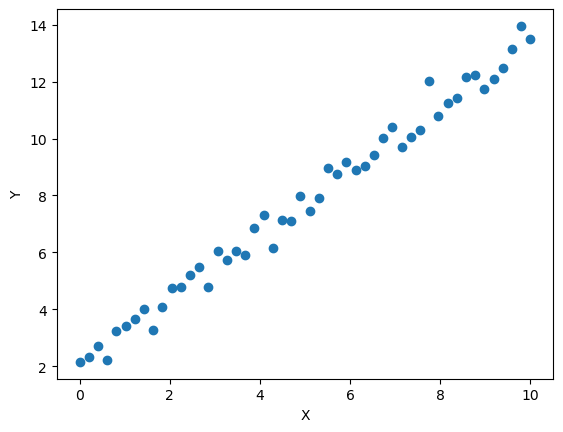

In [3]:
from matplotlib.pyplot import figure, show

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(x, y, marker='o', ls='')
frame.set_xlabel('X')
frame.set_ylabel('Y')
show()

### Brute force method to find the minimum

If one loops over a series of values $\beta_0$ and $\beta_1$ in a grid and calculate Chi Squared for every combination, then we can find the combination of parameters which give the minimal Chi Squared.  
The values of Chi Squared as function of the parameters in $\beta$ can be viewed as a landscape with hills and holes.
The deepest hole is the Chi Squared we are looking for. For non-linear models, we can expect multiple minima and only one is the deepest. That is the one we need.

We show you how to create a Chi squared landscape and how to find a minimum with a brute force method:

The shape of the matrix with Chi^2 values is: (400, 400)
Minimum and maximum log10(Chi2):  0.8898424803501712 4.632120714214407
Found minimum log(Chi squared) 0.8898424803501712 for beta0=2.1303258145363397 and beta1=1.132832080200501


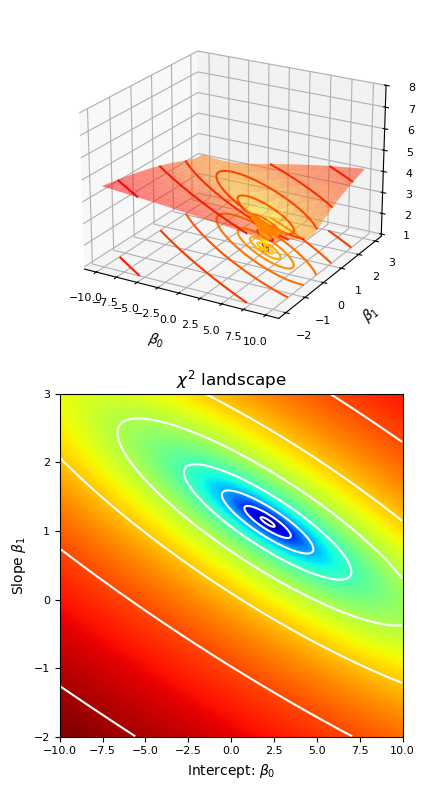

In [4]:
## Change to this for interactive plot:  %matplotlib notebook
# Re-using the values for x and y from the previous cell.

from matplotlib.pyplot import figure, show
from mpl_toolkits.mplot3d import axes3d
def model(x, beta):
    beta0, beta1 = beta         # Parameters which are adjusted by the fit routine
    return beta0 + beta1*x 

def Chi2(x, y, beta):
    ri = y - model(x, beta)
    return (ri*ri).sum()

b0min = -10; b0max = 10   # Range for the beta's in Chi2 landscape
b1min = -2; b1max = 3

# Generate a grid with beta's
b0 = np.linspace(b0min, b0max, 400)
b1 = np.linspace(b1min, b1max, 400)
beta0, beta1 = np.meshgrid(b0, b1)

# Now loop over elements in x and y which saves a lot of for loops.
# The arrays beta0 and beta1 are big two dimensional arrays and looping 
# over smaller arrays x and y saves the number of (nested loops).
# The effect is that we have a much faster creation of the matix with
# Chi squared values.
Chi2 = 0
for i in range(len(y)):
    # Chi2 becomes a matrix with shape=(len(y),len(x))
    Chi2 += (y[i] - (beta0 + beta1*x[i]))**2

print("The shape of the matrix with Chi^2 values is:", Chi2.shape)
Chi2 = np.log10(Chi2)   # To get the values in a decent range
print("Minimum and maximum log10(Chi2): ", Chi2.min(), Chi2.max())
      
# Some NumPy trickery to get the index of the minimum
ind = np.unravel_index(np.argmin(Chi2, axis=None), Chi2.shape)
print(f"Found minimum log(Chi squared) {Chi2[ind]} for beta0={beta0[ind]} and beta1={beta1[ind]}")

fig = figure(figsize=(6,8))

zmin = Chi2[ind]
fr = fig.add_subplot(2,1,1, projection="3d", azim=-60, elev=22)
fr.plot_surface(beta0, beta1, Chi2, cmap="autumn_r", lw=0.5, rstride=25, cstride=25, alpha=0.5)
fr.scatter( beta0[ind], beta1[ind], Chi2[ind], marker='o', color='blue')
fr.contour(beta0, beta1, Chi2, offset=zmin, cmap="autumn_r", linestyles="solid")
fr.contour(beta0, beta1, Chi2, linestyles="solid", colors='r')
fr.tick_params(axis='both', which='major', labelsize=8)
fr.set_zlim(zmin,8)
fr.set_xlabel(r'$\beta_0$')
fr.set_ylabel(r'$\beta_1$')
fr.set_zlabel(r'$\log{\chi^2}$')

frame = fig.add_subplot(2,1,2)
extent = [b0min, b0max, b1min, b1max]    # Needed to match image and contours for the same grid coordinates
frame.imshow(Chi2, interpolation='none', origin='lower', extent=extent, cmap='jet')
frame.contour(Chi2, origin='lower', colors='w', extent=extent)
frame.set_xlabel(r"Intercept: $\beta_0$")
frame.set_ylabel(r"Slope $\beta_1$")
frame.set_title(r"$\chi^2$ landscape")
frame.tick_params(axis='both', which='major', labelsize=8)
frame.set_aspect((b0max-b0min)/(b1max-b1min))
fig.tight_layout()
show()

*Figure: A surface plot of the logarithm of Chi Squared as function of two model parameters. A set of contour levels is plotted on the surface plot and also the projected contours are plotted. These contours correspond to the contours on the image in the lower plot. A Fitter routine finds the position of the minimum Chi Squared as function of all parameters in a model.*

## Gradient Descent

### Definition
To find the minimum in our Chi squared landscape, we apply a gradient descent algorithm. This method corrects the values of $\beta$ by calculating the derivative in the parameter landscape (see plots above) at a start position $\beta_0, \beta_1$.  
The derivative of the Chi squared function in the direction of one of the beta's gives us the change in a $\beta$ given a (small) change in the Chi squared function. We subtract this from the original value of $\beta$ to be sure that we move in the direction of a negative slope. In our 3D plot, this is equivalent as finding the lowest value in the plotted plane. 
For an arbitrary number of parameters we can generalize this as:

\begin{equation}
\beta_j := \beta_j-\alpha\frac{\partial}{\partial \beta_j} \chi^2(\beta_0,\beta_1)
\end{equation}

In machine learning tutorials $\alpha$ is called the *learning rate* and is kept constant in the process of gradient descent.  

### Gradient descent for univariate model e.g. $f(x;\hat{\beta}) = \beta_0 + \beta_1 x$
$$
f(x_i;\beta_0, \beta_1) = \beta_0 + \beta_1 x_i
$$

The Chi squared function (let's call it $J$) is defined as:

$$J(\beta_0,  \beta_1) = \frac{1}{N} \sum_{i=0}^n\big(y_i - f(x_i)\big)^2$$
 
Note that we have $N$ data points but because NumPy starts counting from 0, we define $n=N-1$.  
Then for the derivatives we write:

$$\frac{\partial}{\partial \beta_j} J(\beta_0,  \beta_1)= 
\frac{\partial}{\partial \beta_j} \frac{1}{n} \sum_{i=1}^n\big(y_i - f(x_i)\big)^2$$

$$= \frac{\partial}{\partial \beta_j} \frac{1}{N} \sum_{i=0}^n\big(y_i - (\beta_0 + \beta_1.x_i)\big)^2$$

from which we derive the two equations which gives us improved parameters:

\begin{equation}
\frac{\partial J}{\partial \beta_0} = -\frac{2}{N} \sum_{i=0}^n\big( y_i -(\beta_0 + \beta_1 x_i)\big)
\end{equation}

\begin{equation}
\frac{\partial J}{\partial \beta_1} = -\frac{2}{N} \sum_{i=0}^n\big( y_i - (\beta_0 + \beta_1 x_i)\big)\ . x_i
\end{equation}

So, using the learning parameter $\alpha$, we have to update our parameters $\beta_0$ and $\beta_1$ simultaneously as follows:

\begin{equation}
\beta_0 := \beta_0+\alpha \frac{2}{N} \sum_{i=1}^n\big(y_i -  (\beta_0 + \beta_1.x_i)\big)
\end{equation}

\begin{equation}
\beta_1 := \beta_1+\alpha \frac{2}{N} \sum_{i=1}^n\big( y_i - (\beta_0 + \beta_1.x_i)\big)\ x_i
\end{equation}

and we should repeat this until convergence has been reached.

In [5]:
beta0s = 0; beta1s = 0
N = x.size
alpha = 0.01

# Gradient descent:
for i in range(1000):              # This many iterations
    S0 = y - (beta0s + beta1s*x)
    S1 = S0*x
    newbeta0 = beta0s + alpha*2*S0.sum()/N
    newbeta1 = beta1s + alpha*2*S1.sum()/N
    beta0s = newbeta0
    beta1s = newbeta1

print(f"Gradient descent gives Intercept beta0={beta0s:.3f} and slope beta1={beta1s:.3f})")

Gradient descent gives Intercept beta0=2.117 and slope beta1=1.133)


If you read the notebook about linear models, you wonder why we apply this gradient method if for a linear model we already know how to derive the best fit parameters. Well, it is written here as an example and a first step towards more sophisticated methods:

* Such methods do not need expressions for the gradients of the parameters but can use methods to numerically approach the gradients
* Such methods can deal with both linear and non-linear models

However:

* When dealing with complex Non-Linear models, there can be more holes in a Chi squared landscape. To find the right one, our start values (``beta0s``, ``beta1s``) need to be close to the right local minimum.

**Initial estimates**  
These start values are called *initial estimates* and play an important role in least squares fitting procedures.

One of the functions that provides a least squares fitting procedure based on gradient descent for both linear and non-linear is discussed in the next section.

## Simple fitting with ``scipy.optimize.curve_fit``

Function ``curve_fit()`` is easy to use. It is a wrapper for function ``scipy.optimize.leastsq()`` (in the latest version of scipy it seems to be based on the newer ``scipy.optimize.least_squares()``)  which we will discuss later.

In the next example we want to fit the parameters $\beta_0$ and $\beta_1$ in the model $f(x;\hat{\beta}) = \beta_0 + \beta_1 x$ using the artificial data from previous cells. Function ``curve_fit()``  
(see also https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html )  
has two return values which we called ``popt`` and ``pcov``. For now we are only interested in the fitted model parameters in ``popt`` which we call ``beta`` in our code

Please open the SciPy page about ``curve_fit()`` to fill in details that we miss here.

Intercept beta0=2.1295428224431054, slope beta1=1.1315176390453072


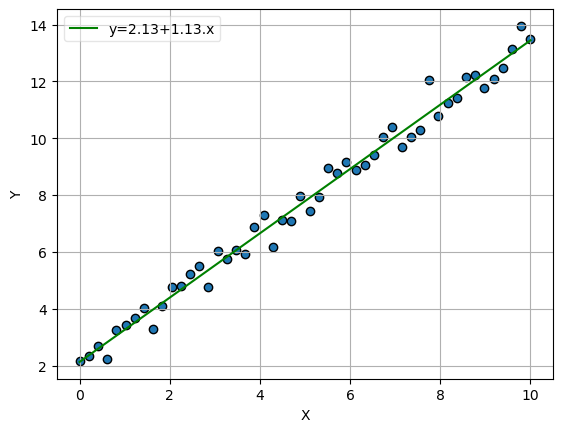

In [6]:
from matplotlib.pyplot import subplots, show
from scipy.optimize import curve_fit

def model(x, beta0, beta1):
    """The model with parameters a and b. Note that for the Hubble relation we fix a to 0.0"""
    return beta0 + beta1*x

# Do the fitting
beta, pcov = curve_fit(model, x, y)
print(f"Intercept beta0={beta[0]}, slope beta1={beta[1]}")

# Calculate end points for the best straight line
X = np.array([x.min(),x.max()])
Y = model(X, beta[0], beta[1])

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='o', ec='k')
frame.set_xlabel('X')
frame.set_ylabel('Y')
label = f"y={beta[0]:.2f}+{beta[1]:.2f}.x"
frame.plot(X, Y, label=label, color='green')
frame.legend(fancybox=True, framealpha=0.5)
frame.grid(True)

show()

## How to get the standard errors on the fitted parameters from ``curve_fit()``

The standard error of a best fit parameter given a sample, is an estimate of how far the sample's parameter is likely to be from the population parameter.

**Important**: Publishing best fit model parameters without their uncertainties is considered bad practice.

A number of NLLS fit routines return the (co)variance matrix which stores all parameter variances and co-variances.
The variances are on the diagonal of that matrix 
and standard errors are the square root values of the diagonal elements. 

The covariance matrix that is returned by ``curve_fit()`` in parameter ``pcov``.
So we can calculate the standard errors with the following code:

    stderr = np.sqrt(np.diag(pcov))
 
**Warning:**
Function ``curve_fit()`` has a parameter ``absolute_sigma`` which is set to False by default. This is the best option if you don't have weights for the data. The fitter assumes that all data points have a weight of 1.0. But then the errors from the covariance do not reflect the standard errors as what would have been obtained by alternative methods and the fitter scales these errors automatically as if the fit was perfect: $\chi_{\nu}^2 = 1$. But there are pitfalls here.

* **1.** The expectation value of $\chi_{\nu}^2$ is only 1.0 for linear models
* **2.** The residuals must be Gaussian distributed
* **3.** The model and fit must be optimal to assume $\chi_{\nu}^2 = 1$

So for equal- and relative weights we have no reliable way to estimate standard errors.

As soon your data has weights derived from the real standard deviations of the data points, you have to set ``absolute_sigma`` to True.

In [7]:
dbeta = np.sqrt(np.diag(pcov))   # Standard error
print("Standard errors for intercept and slope:", dbeta)

print("Best fit model parameters")
s = f"Intercept beta0 = {beta[0]:.2f} \u00B1 {dbeta[0]:.2f}"
print(s)
s = f"Slope     beta1 = {beta[1]:.2f} \u00B1 {dbeta[1]:.2f}"
print(s)

Standard errors for intercept and slope: [0.11201249 0.0193029 ]
Best fit model parameters
Intercept beta0 = 2.13 ± 0.11
Slope     beta1 = 1.13 ± 0.02


### A non linear model

Function $f(x;\hat{\beta}) = \beta_0 + \beta_1 sin(\beta_2 x+\beta_4)$ represents a non-linear model. That becomes obvious if we try to find the derivative of the Chi squared function with respect to $\beta_2$. You will observe that its derivative depends on $\beta_2$ and therefore the model is non-linear.

We create artificial data for this model and use ``curve_fit()`` to find the best fit parameters.

In [8]:
def f(x, beta0, beta1, beta2, beta3):
    """Our model y = beta0 + beta1*sin(beta2*x+beta3)"""
    y = beta0 + beta1*np.sin(beta2*x+beta3)
    return y

N = 40
x = np.linspace(-1, 10, N)
beta0 = 2
beta1 = 2
beta2 = 0.5
beta3 = 0.5*np.pi
y = f(x, beta0, beta1, beta2, beta3) + np.random.normal(loc=0.0, scale=0.5, size=N)

sigma = np.abs(np.random.normal(0.8, 0.5, y.size))  # Errors in the observation y_i

In [9]:
# Do the fitting
beta, pcov = curve_fit(f, x, y, p0=(0,1,1,0))
print(f"Betas", beta)

dbeta = np.sqrt(np.diag(pcov))   # Standard error
print("Standard errors for intercept and slope:", dbeta)

Betas [2.2388697  2.12331648 0.47409949 1.73571571]
Standard errors for intercept and slope: [0.12750798 0.12024811 0.02645617 0.16362096]


In the next cell we plot the data.   

**Note that we unpack the fitted** $\beta$ **array with** ``*beta``.

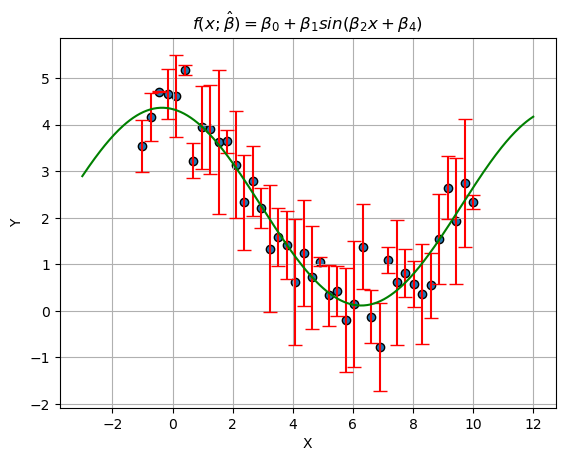

In [10]:
from matplotlib.pyplot import subplots, show

X = np.linspace(-3, 12, 400)
Y = f(X, *beta)    # Note that *beta unpacks the values for beta0, beta1 etc.

fig, fr = subplots()
fr.scatter(x, y, marker='o', ec='k')
fr.errorbar(x, y, sigma, color='r', marker='', label=r"$\sigma_i$", ls='', capsize=5)
fr.plot(X,Y, color='green')
fr.set_xlabel('X')
fr.set_ylabel('Y')
fr.grid()
fr.set_title(r"$f(x;\hat{\beta}) = \beta_0 + \beta_1 sin(\beta_2 x+\beta_4)$")
show()

#### Can I also use a variable argument list for the definition of my model?

Yes, this is possible and very convenient if you have a large number of arguments to pass. In the model function that you define, you unpack the argument into variables for your function. Note that the order of the initial parameters in ``p0`` must be the same. To let the function know how many parameters it has to fit, you need to give the right number
of parameters in ``p0`` (which are the initial estimates). We give an example:


In [11]:
def f2(x, *beta_hat):
    """Our model y = beta0 + beta1*sin(beta2*x+beta3)
    Note that beta_hat is entered as a variable length argument list"""
    beta0, beta1, beta2, beta3 = beta_hat
    y = beta0 + beta1*np.sin(beta2*x+beta3)
    return y

# Initial estimates
beta0 = 0
beta1 = 1
beta2 = 1
beta3 = 0
beta, pcov = curve_fit(f2, x, y, p0=(beta0, beta1, beta2, beta3))
print(f"Betas", beta)

Betas [2.2388697  2.12331648 0.47409949 1.73571571]


### Calculation of the reduced Chi squared
Regrettably, the function does not return a value for the reduced Chi squared. 
But this can be calculated easily. We first have to find the weighted residuals, sum them and then divide by the degrees of freedom, which for this model with 4 parameters is $N-4$.

The code in the next cell shows how to use the variable length argument list to call ``f2()`` and how to derive the reduced Chi squared.

In [12]:
ri = y-f2(x,*beta)
chi2 = (ri*ri).sum()
rchi2 = chi2/(N-4)
print("Reduced Chi squared:", rchi2)

Reduced Chi squared: 0.26341924518370796


### ``Curve_fit()`` with weigths

Function ``curve_fit()`` is also suitable to make fits with data for which we have a standard deviation available.
These standard deviations are entered in argument ``sigma``. We test this with artificial weights and derive the standard errors for the fitted parameters from scaled covariances.

In [13]:
beta, pcov = curve_fit(f, x, y, sigma=sigma, p0=(0,1,1,0))
print("Betas:          ", beta)

dbeta = np.sqrt(np.diag(pcov))   # Standard error
print("Standard errors:", dbeta)

Betas:           [2.52609568 2.2249212  0.46838955 1.58063732]
Standard errors: [0.06505505 0.09032914 0.01456864 0.10180957]


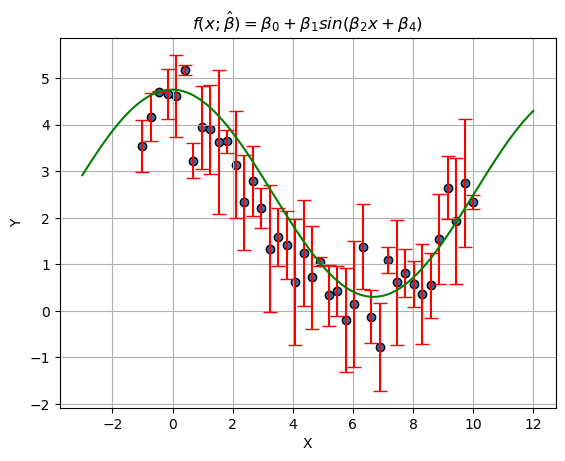

In [14]:
X = np.linspace(-3, 12, 400)
Y = f2(X, *beta)    # Note that *beta unpacks the values for beta0, beta1 etc.

fig, fr = subplots()
fr.scatter(x, y, marker='o', ec='k')
fr.errorbar(x, y, sigma, color='r', marker='', label=r"$\sigma_i$", ls='', capsize=5)
fr.plot(X,Y, color='green')
fr.set_xlabel('X')
fr.set_ylabel('Y')
fr.grid()
fr.set_title(r"$f(x;\hat{\beta}) = \beta_0 + \beta_1 sin(\beta_2 x+\beta_4)$")
show()

### Unscaled standard errors
If we trust the errors in our observations $y_i$ as weights, then we have to set argument ``absolute_sigma`` to ``True``:

In [15]:
beta, pcov = curve_fit(f, x, y, sigma=sigma, p0=(0,1,1,0), absolute_sigma=True)
print("Betas:          ", beta)

dbeta = np.sqrt(np.diag(pcov))   # Standard error
print("Standard errors:", dbeta)

Betas:           [2.52609568 2.2249212  0.46838955 1.58063732]
Standard errors: [0.04783621 0.06642073 0.0107126  0.07486251]


### Calculation of reduced Chi squared for fit with weighted data

In [16]:
ri = (y-f(x,*beta))/sigma
chi2 = (ri*ri).sum()
rchi2 = chi2/(N-4)
print("Reduced Chi squared:", rchi2)

Reduced Chi squared: 1.8494747209606512


### Disadvantages of function ``curve_fit()``

* The function does not return a goodness of fit estimate (e.g. no Chi squared value). You have to create your own code for this.
* There is no way to modify an *objective function*, see next section

## Fitting with SciPy's LEASTSQ

In this section we discuss ``scipy.optimize.leastsq()`` which is the work horse of the fitting functions. Function ``curve_fit()`` is a wrapper for ``leastsq()`` and has been developed to make the call to that function easier but the machinery is the same as in ``leastsq()``. The latter allows us to define different residual functions for example for robust or orthogonal fitting.

### The objective function

A least squares fit method is an algorithm that minimizes a so-called objective function for N data points $(x_i,y_i), i=0, ...,N-1$. These data points are measured and often $y_i$ has a measurement error that is much smaller than the error in $x_i$. Then we call $x$ the independent and $y$ the dependent variable. For our 'Hubble' data that we used in this course we assume that we measured the distances with greater precision than the velocities.

Fitting functions adjust the parameters of a model function by finding a minimum of a so-called **objective** function. This objective function returns a sum of residual values $r_i$:

$$S = \sum\limits_{i=0}^{n} r_i$$

Objective functions are also called *merit* functions.

An objective function is a maximum-likelihood estimator (MLE) when it maximizes the "agreement" of the selected model with the observed data. In the method of least squares the objective function:

$$S = \sum\limits_{i=0}^{n} \left(y_i - f(x_i, \hat{\beta})\right)^2$$

is a maximum-likelihood estimator. From this, the name least squares is derived. For ``S`` we often use $\chi^2$. The reason is that if we were able to repeat our measurements many times, the resulting values of ``S`` would be distributed as the so called $\chi^2$ distribution. This distribution has some statistical properties which we can use to qualify our fit.

Least squares fit functions differ in the way you need to define the objective function. Both ``kmpfit.Fitter()`` as ``scipy.optimize.leastsq()`` need only a residuals function $r_i = y_i - f(x_i, \vec{\beta})$. The fitters calculate the square of the residuals and sum the result themselves. They vary the parameter until a minimum is found for this sum.

Functions like ``scipy.optimize.curve_fit()`` hide the definition of the objective function and are therefore less flexible (i.e. you cannot experiment with alternative objective functions).

**Examples of alternative objective functions**:

*    The (absolute value of the) distance in y direction: $|y_i-f(x_i)|$   where $y_i$ is an observed data point
*    The perpendicular distance: $\frac{|y_i-f(x_i)|}{\sqrt{(1+\beta_1^2)}}$ if the model is $Y = \beta_0 + \beta_1 X$

### Define a residuals function for ``leastsq()``

The work horse versions of the fitter functions in NumPy and SciPy work with a definition of an objective function which is different than what we learned from ``curve_fit()`` which needs a function for the model. 

First we will discuss a setup for ``scipy.optimize.leastsq()``
To facilitate writing an residual function we first define the model. Argument ``beta`` contains the parameters we want to fit.

    def model(beta, x):
        beta0, beta1 = beta              # Parameters which are adjusted by leastsq
        return beta0 + beta1*x 
        
then a residual function could be:

    def residuals(beta, x, y):           # Residuals function needed by leastsq
        x, y = data
        return y - model(beta,x)
        
If there are weights associated with the data, then it is up to you how to enter and use these weights. Most probably you want to use:


    def residuals(beta, x, y, sigy):     # Residuals function needed by leastsq
        x, y = data
        return (y-model(beta,x))/sigy
 

The fit routine does the squaring and summing. ``leastsq()`` fits linear and non-linear models so it requires initial estimates. For linear models, it does not matter much what the values are (there is only one minimum in the Chi squared landscape) but for non-linear models they should be reasonable values.

``leastsq()`` has the function (pointer) to the residuals function as first argument. Then follow the sequence with initial estimates. Third argument is special. It needs a tuple with the arrays with data points. Finally we use ``full_output=1`` to get a full report from which we derive some useful information. 

For a detailed description of what is returned, see:  
https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.leastsq.html

We need to unpack the result. The first variable will contain the values of all fitted parameters. The second variable contains the covariance matrix.

The template code becomes:

In [17]:
# Some Hubble data with 1 sigma errors on both distance and velocity
import numpy as np
data = [
         8.49,      2094.75,    0.3,           200,
         35.48,     2320.87,    2.2,           220,
         35.48,     1224.9,     3.0,           180,
         11.34,     872.13,     1.2,           180,
         7.12,      432.2,      0.4,           170,
         9.82,      751,        0.3,           175,
         23.66,     1410,       2.3,           170,
         44,        2700,       4.0,           210,
         66.7,      5292,       5.3,           220,
         52.4,      2550,       5.2,           200,
         55,        5253,       6.1,           250,
         25.6,      2419,       3.2,           210,
         26.19,     2158,       2.8,           210]


data = np.asarray(data)
x = data[0::4]; y = data[1::4]
sigx= data[2::4]; sigy= data[3::4]

In [18]:
# The result of a fit without weights:
beta_lsq = [224.92243799,  66.17289251]

In [19]:
import numpy as np
from scipy.optimize import leastsq 

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x 
  
# A residuals function    
def residuals(beta, x, y, sigy):
    return (y - model(beta,x))/sigy

beta_start = [0, 70.0]          # Initial estimates for beta0 and beta1
data = (x, y, sigy)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1) 
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results 

# Convert unscaled standard errors to scaled standard errors 
# No need to understand this code
if not pcov is None: 
    # Note that 'fvec' are residuals, not function 
    # values according to the documentation 
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()       
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic 
    dof = len(fvec) - len(beta)              # Number of degrees of freedom   
    # Uncertainties for unweighted data 
    sderr = perror * np.sqrt(chi2/dof) 

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_lsqwei = beta

====== LEASTSQ RESULTS ==========
Params:                          [231.02067869  62.75111138]
Unscaled standard error(s):      [100.263194     3.00157007]
Scaled standard error(s):        [414.00668299  12.39408021]
Degrees of freedom:              11
Chi^2 min:                       187.55313055055697
Reduced Chi squared:             17.05028459550518
Iterations:                      Not returned by leastsq()
Number of function evaluations:  7


[224.92243799, 66.17289251] [231.02067869  62.75111138]


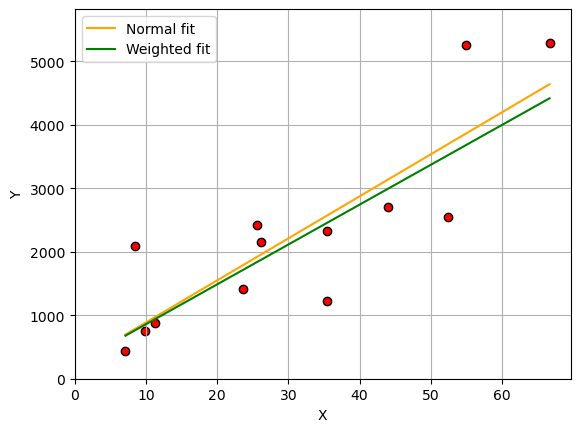

In [20]:
from matplotlib.pyplot import figure, show

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='o', ec='k', color='r')
xmin = x.min(); xmax = x.max()
ymin = model(beta_lsq,xmin); ymax = model(beta_lsq,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Normal fit", color='orange')
ymin = model(beta_lsqwei,xmin); ymax = model(beta_lsqwei,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Weighted fit", color='green')
print(beta_lsq, beta_lsqwei)
frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.grid()
frame.legend()
show()

### Robust fitting with ``leastsq()``

With robust fitting, we do not square the residuals but take their absolute values. This is still a maximum likelihood estimator but one that is less sensitive to outliers. With ``leastsq`` we have the option to modify the objective function so when we take the square root of the absolute values of the residulals, then the fitter will square them and the effect is that you minimize  $|y_i-f(x_i)|$. The objective function is:

\begin{equation}
r_i = |y_i-f(x_i)|
\end{equation}

With ``leastsq()`` you can modify the objective function to implement this objective function as follows:

In [21]:
from scipy.optimize import leastsq 

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x 
  
# A residuals function    
def residuals(beta, x, y):
    return np.abs(y - model(beta,x))**0.5

beta_start = [0, 70.0]   # Initial estimates for beta0 and beta1
data = (x,y)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1) 
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results 

# Convert unscaled standard errors to scaled standard errors 
# No need to understand this code
if not pcov is None: 
    # Note that 'fvec' are residuals, not function 
    # values according to the documentation 
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()       
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic 
    dof = len(fvec) - len(beta)              # Number of degrees of freedom   
    # Uncertainties for unweighted data 
    sderr = perror * np.sqrt(chi2/dof) 

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_robust = beta

====== LEASTSQ RESULTS ==========
Params:                          [150.21553271  61.1796764 ]
Unscaled standard error(s):      [0.03004704 0.00216485]
Scaled standard error(s):        [0.79733039 0.05744649]
Degrees of freedom:              11
Chi^2 min:                       7745.7960853093555
Reduced Chi squared:             704.1632804826687
Iterations:                      Not returned by leastsq()
Number of function evaluations:  142


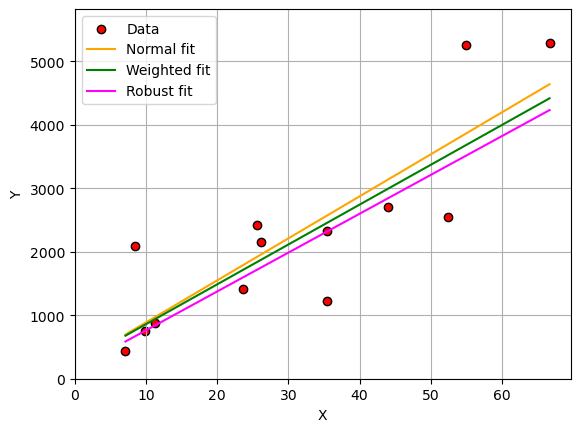

In [22]:
from matplotlib.pyplot import figure, show

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='o', ec='k', color='r', label="Data")
xmin = x.min(); xmax = x.max()
ymin = model(beta_lsq,xmin); ymax = model(beta_lsq,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Normal fit", color='orange')
ymin = model(beta_lsqwei,xmin); ymax = model(beta_lsqwei,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Weighted fit", color='green')
ymin = model(beta_robust,xmin); ymax = model(beta_robust,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Robust fit", color='magenta')
frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.grid()
frame.legend()
show()

#### Robust fitting, another example
We want to give another example which shows much better what the influence is of an outlier on normal- and robust fitting:

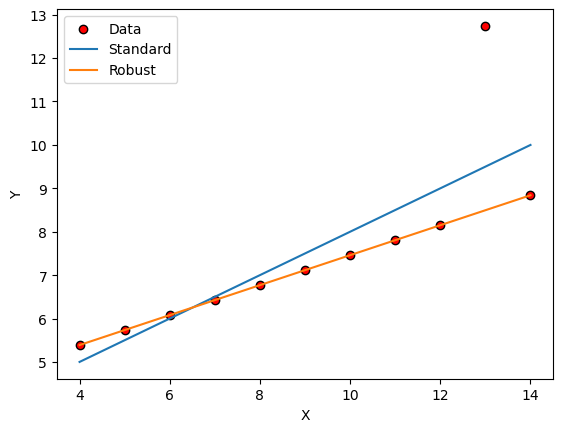

In [23]:
import numpy as np
from matplotlib.pyplot import figure, show

def residuals_standard(beta, x, y):           # Residuals function needed by leastsq
    x, y = data
    return y - model(beta,x)

def residuals_robust(beta, x, y):
    return np.abs(y - model(beta,x))**0.5

x1 = np.array([10.0, 8.0, 13.0, 9.0, 11.0, 14.0, 6.0, 4.0, 12.0, 7.0, 5.0])
y1 = np.array([7.46, 6.77, 12.74, 7.11, 7.81, 8.84, 6.08, 5.39, 8.15, 6.42, 5.73])

beta_start = [1, 1]         # Initial estimates for beta0 and beta1
data = (x1, y1)             # You need to pack your data in a tuple
result = leastsq(residuals_standard, beta_start, args=data, full_output=1) 
(beta_stand, pcov, infodict, errmsg, ier) = result

beta_start = [1, 1]         # Initial estimates for beta0 and beta1
data = (x1, y1)             # You need to pack your data in a tuple
result = leastsq(residuals_robust, beta_start, args=data, full_output=1) 
(beta_rob, pcov, infodict, errmsg, ier) = result


fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x1, y1, marker='o', color='r', ec='k', label="Data")
xmin = x1.min(); xmax = x1.max()
ymin = model(beta_stand,xmin); ymax = model(beta_stand,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Standard")
ymin = model(beta_rob,xmin); ymax = model(beta_rob,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Robust")
frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.legend()
show()

Which is a much better fit because the distance to the outlier is not squared with robust fitting.

### Orthogonal fitting with ``leastsq`` 

Another challenge is to fit with data which has comparable errors in x and y. Then we do not want to minimize the vertical distances, but we want to minimize the perpendicular distances between y values and model.

For a straight line model  $Y = \beta_0 + \beta_1 X$ we can define the objective function:

\begin{equation}
r_i = \frac{|y_i-f(x_i)|}{\sqrt{(1+\beta_1^2)}}
\end{equation}

In the notebook about Orthogonal Fitting with ODR, we give more background for this formula. For now, we focus on how to implement it:


In [24]:
from scipy.optimize import leastsq 

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta
    return beta0 + beta1*x 
  
# A residuals function    
def residuals(beta, x, y):
    beta0, beta1 = beta
    return np.abs(y - model(beta,x))/(1+beta1**2)**0.5


beta_start = [0, 70.0]   # Initial estimates for beta0 and beta1
data = (x,y)             # You need to pack your data in a tuple
result = leastsq(residuals, beta_start, args=data, full_output=1) 
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results 

# Convert unscaled standard errors to scaled standard errors 
# No need to understand this code
if not pcov is None: 
    # Note that 'fvec' are residuals, not function 
    # values according to the documentation 
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()       
    perror = np.sqrt(pcov.diagonal())        # Trusted as the weights are realistic 
    dof = len(fvec) - len(beta)              # Number of degrees of freedom   
    # Uncertainties for unweighted data 
    sderr = perror * np.sqrt(chi2/dof) 

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Unscaled standard error(s):     ", perror   )
print( "Scaled standard error(s):       ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Iterations:                     ", "Not returned by leastsq()" )
print( "Number of function evaluations: ", infodict['nfev'] )

beta_orth = beta

====== LEASTSQ RESULTS ==========
Params:                          [-594.84397769   92.73031727]
Unscaled standard error(s):      [56.50624782  1.62996755]
Scaled standard error(s):        [614.04399199  17.71258615]
Degrees of freedom:              11
Chi^2 min:                       1298.9687955232562
Reduced Chi squared:             118.08807232029602
Iterations:                      Not returned by leastsq()
Number of function evaluations:  13


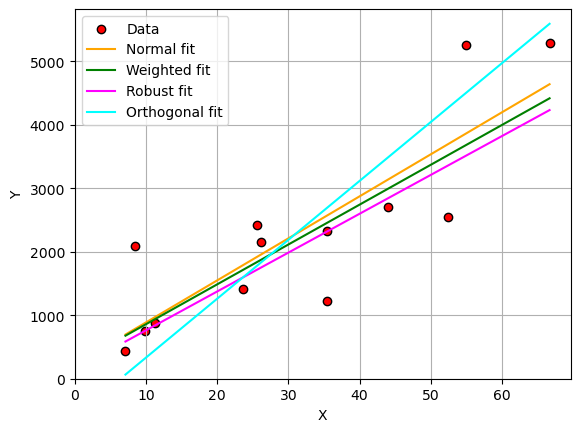

In [25]:
from matplotlib.pyplot import figure, show

from matplotlib.pyplot import figure, show

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, marker='o', ec='k', color='r', label="Data")
xmin = x.min(); xmax = x.max()
ymin = model(beta_lsq,xmin); ymax = model(beta_lsq,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Normal fit", color='orange')
ymin = model(beta_lsqwei,xmin); ymax = model(beta_lsqwei,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Weighted fit", color='green')
ymin = model(beta_robust,xmin); ymax = model(beta_robust,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Robust fit", color='magenta')
ymin = model(beta_orth,xmin); ymax = model(beta_orth,xmax)
frame.plot([xmin, xmax], [ymin, ymax], label="Orthogonal fit", color='cyan')

frame.set_xlabel('X')
frame.set_ylabel('Y')
frame.set_xlim(0, None)
frame.set_ylim(0, 1.1*y.max())
frame.grid()
frame.legend()
show()

#### Conclusion

Different objective functions give different fits. For every type of data, there can be a most appropriate objective function. For astronomical data we have often measurements with comparable errors in both the dependent and the independent variable and orthogonal fitting can be interesting then.  

We discuss a powerful function for orthogonal fitting in a notebook about Orthogonal Distance Regression (ODR).

### ``leastsq()``: Fitting the model parameters of 3 Gaussians with fixed offset

The next example shows how to use ``leastsq()`` with a more complex model. The model consists of three Gaussians. The offset of these is fixed to 0.0, so the offset will not be fitted.

====== LEASTSQ RESULTS ==========
Params:                          [-0.91950842  5.48183801  0.33749116  1.65488393  9.45875694  1.77513039
  1.13166927 11.72042017  0.75420044]
Errors from Covariance matrix:   [0.56983428 0.23757922 0.2527076  0.36987346 1.20505218 0.88717359
 1.23062305 0.3449712  0.63637551]
Standard errors:                 [0.22027854 0.09184004 0.09768816 0.14298049 0.46583216 0.34295112
 0.47571699 0.13335413 0.24600112]
Degrees of freedom:              155
Chi^2 min:                       23.162153362859645
Reduced Chi squared:             0.1494332475023203
Number of function evaluations:  664


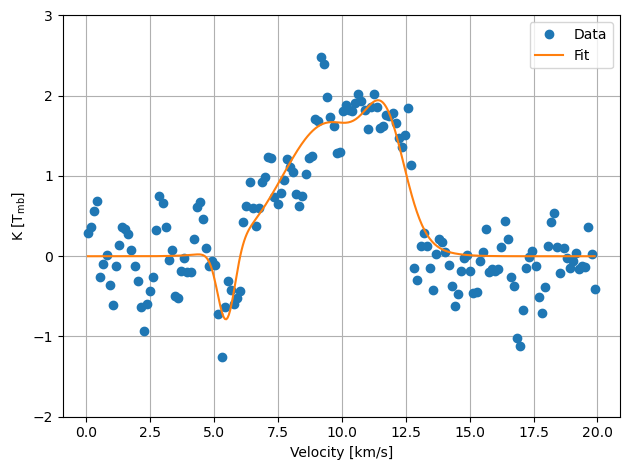

In [26]:
import numpy as np
from scipy.optimize import leastsq
from matplotlib.pyplot import subplots, show
from pathlib import Path
import os

path = Path(f"{os.path.expanduser('~')}/DATA/pixel40.dat")

def gaussian(x, height, center, width):
    """Helper function: Gaussian without an offset"""
    return height*np.exp(-(x-center)**2/(2*width**2))

def model(beta, x):
    """The model: 3 Gaussians"""
    h1, c1, w1, h2, c2, w2, h3, c3, w3 = beta     # Parameters which are adjusted by leastsq
    return gaussian(x,h1,c1,w1) + gaussian(x,h2,c2,w2) + gaussian(x,h3,c3,w3)

def residuals(beta, x, y):  # Residuals function needed by leastsq
    # The standard residuals function. Leastsq() does the squaring
    return y - model(beta,x)

V, T = np.loadtxt(path, unpack=True)

beta_start = [-1.53, 5.578, 1.158, 0.93, 6.27, 2.783, 2.06, 10.474, 3.715]
result = leastsq(residuals, beta_start, args=(V,T), full_output=1)
(beta, pcov, infodict, errmsg, ier) = result       # Unpack tuple with results

# Convert covariance errors to standard errors
if not pcov is None:
    # Note that 'fvec' are residuals, not function
    # values according to the documentation
    fvec = infodict['fvec']
    chi2 = (fvec**2).sum()
    perror = np.sqrt(pcov.diagonal())        # Trusted only when the weights are realistic
    dof = len(fvec) - len(beta)              # Number of degrees of freedom
    # Uncertainties for unweighted data
    sderr = perror * np.sqrt(chi2/dof)

print( "====== LEASTSQ RESULTS =========="          )
print( "Params:                         ", beta     )
print( "Errors from Covariance matrix:  ", perror   )
print( "Standard errors:                ", sderr    )
print( "Degrees of freedom:             ", dof      )
print( "Chi^2 min:                      ", chi2     )
print( "Reduced Chi squared:            ", chi2/dof )
print( "Number of function evaluations: ", infodict['nfev'] )


# Plot the results
fig, frame = subplots()
frame.plot(V, T, marker='o', ls='', label="Data")
x = np.linspace(V.min(), V.max(), 400)
y = model(beta, x)
frame.plot(x,y, label="Fit")
frame.set_ylim(-2,3)
frame.grid(True)
frame.set_ylabel(r"K [T$_\mathrm{mb}$]", fontsize=10)
frame.set_xlabel("Velocity [km/s]", fontsize=10)
frame.legend(loc='upper right')
fig.tight_layout()
show()


## (OPTIONAL) KMPFIT

This fitter has been made at Kapteyn when a very fast and robust fitter was needed for Python.

In ``kmpfit`` the parameters are passed first and the data second. 

    def model(beta, x):
        beta0, beta1 = beta              # Parameters which are adjusted by kmpfit
        return beta0 + beta1*x 
        
then a residual function could be:

    def residuals(beta, data):           # Residuals function needed by kmpfit
        x, y = data
        return y - model(beta,x)

In [27]:
from kapteyn import kmpfit

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta        # Parameters which are adjusted by kmpfit
    return beta0 + beta1*x 
  
# A residuals function    
def residuals(beta, data):  # Residuals function needed by kmpfit
    x, y = data
    return y - model(beta,x)

d = np.array([42, 6.75, 25, 33.8, 9.36, 21.8, 5.58, 8.52, 15.1])
v = np.array([1294, 462, 2562, 2130, 750, 2228, 598, 224, 971])


### Initialize the fitter routine in ``kmpfit``

In ``kmpfit`` we create an object from class ``Fitter()``. Its arguments are a residuals function in argument ``residuals`` and a tuple with the data arrays in argument ``data``. 

The result is an object which has a method called ``fit()``. This is the work horse of the fit procedure. It needs start values for its model parameters in the order as defined in the model. There is a category of fit problems where these initial values are not important (linear models) and a category where the quality of these initial values is essential for a good fit (non-linear models). We will explain more about this in a later section in this notebook.

By inspection of our plot we estimate start values for model parameters $\beta_0$ and $\beta_1$. The values 0 and 70 seem reasonable. The initial estimates are packed into a tuple ``beta_start = (0, 70)`` and given in argument ``params0``. The return value of method ``fit()`` is a status. If ``status == 0`` we have a problem. If not, we can use attributes of the ``Fitter() object`` to print results.

In [28]:
beta_start = (0, 70)
fitobj = kmpfit.Fitter(residuals=residuals, data=(d,v))
status = fitobj.fit(params0=beta_start)
print("Was fit successful?", bool(status))

Was fit successful? True


### Results stored in attributes of the Fitter object

For a list of ``Fitter()`` attributes, see: https://www.astro.rug.nl/software/kapteyn/kmpfit.html#module-kmpfit

The result of a fit are the model parameters for which the model is closest to the data. These parameters are stored in attribute ``params`` in the same order as they were stored in ``beta_start``.

So we can wite:

    beta0, beta1 = fitobj.params
    
To get estimates of the 1 sigma errors of the fitted parameters, we use the values in attribute ``stderr``. We will explain later why we use these errors when we fit without weighting the data (as in our example). 

    dbeta0, dbeta1 = fitobj.stderr
    

In [29]:
beta0, beta1 = fitobj.params
dbeta0, dbeta1 = fitobj.stderr
s = u"Fitted intercept beta0={} \u00B1 {}".format(beta0, dbeta0)
print(s)
s = "Fitted slope beta1={} \u00B1 {}".format(beta1, dbeta1)
print(s)

Fitted intercept beta0=414.71769219487254 ± 413.0744314560506
Fitted slope beta1=44.58662808085461 ± 18.531843672064927


### Generating a status report after a fit

An overview of the fit results can be generated with:

In [30]:
print("\nFit status kmpfit:"                           )
print("===================="                           )
print("Best-fit parameters:        ", fitobj.params    )
print("Asymptotic error:           ", fitobj.xerror    )
print("Error assuming red.chi^2=1: ", fitobj.stderr    )  
print("Chi^2 min:                  ", fitobj.chi2_min  )
print("Reduced Chi^2:              ", fitobj.rchi2_min )
print("Iterations:                 ", fitobj.niter     )
print("Number of free pars.:       ", fitobj.nfree     )
print("Degrees of freedom:         ", fitobj.dof       )
print("Covariance matrix:        \n", fitobj.covar     )


Fit status kmpfit:
Best-fit parameters:         (414.71769219487254, 44.58662808085461)
Asymptotic error:            [0.60915502 0.02732865]
Error assuming red.chi^2=1:  [413.07443146  18.53184367]
Chi^2 min:                   3218837.2278252216
Reduced Chi^2:               459833.8896893174
Iterations:                  2
Number of free pars.:        2
Degrees of freedom:          7
Covariance matrix:        
 [[ 0.37106984 -0.01393382]
 [-0.01393382  0.00074685]]


### Plotting a result

Usually the best way to assess the quality of a fit is to plot the results. Next we demonstrate how we use our model function to calculate values for our fit using the optimal model parameters (``a`` and ``b``):

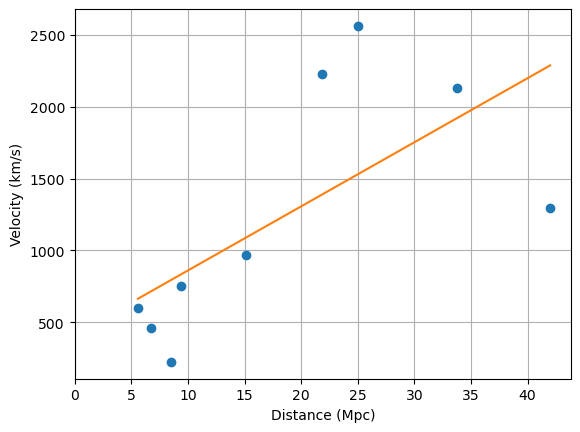

In [31]:
from matplotlib.pyplot import figure, show

beta = fitobj.params

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(d, v, marker='o', ls='')
dmin = d.min(); dmax = d.max()
vmin = model(beta,dmin); vmax = model(beta,dmax)
frame.plot([dmin, dmax], [vmin, vmax])
frame.set_xlabel('Distance (Mpc)')
frame.set_ylabel('Velocity (km/s)')
frame.set_xlim(0,None)
frame.grid()
show()

### Weights

In the examples above, each data point contributes in the same way to the result. Each data point got a *unit weight* (1.0) and we applied the procedure of *unit weighting*. This explains why our asymptotic errors are unrealistically  small.

If the measurements were repeated several times and for each mesurement of distance and velocity a standard deviation was calculated (1 sigma error on the **data**). We can use these values to weight the fit. The smaller the error, the bigger the weight of the data point. This can make a big difference for the final model parameters.  If we have an array of standard errors we should extend our ``data`` tuple in the ``Fitter()`` object with an extra variable. But we need also to change our residual function. The function that leads to a maximum-likelihood estimator is the difference between data points and models divided by sigma. For our model, we summarize this in the next formula:

$$\chi^2(x, \vec{\beta}) = \sum\limits_{i=0}^n \left( \frac{y_i-(\beta_0+\beta_1 x)}{\sigma_i} \right)^2$$

Again, we only need to define the residual divided by $\sigma_i$.   
Note: The fitter routine does the squaring and summing.  
The residuals function for our problem becomes:

    def residuals(beta, data):  # Residuals function needed by kmpfit
        x, y, err = data
        return (y - model(beta,x))/err
        
Note that $\sigma$ is usually half the length of an error bar in a plot. Be careful if an alternative least squares fit function requires weights. Sometimes the required weights must be given as $1/\sigma^2$. 

In [32]:
from kapteyn import kmpfit

# The model, usually a function of x
def model(beta, x):
    beta0, beta1 = beta        # Parameters which are adjusted by kmpfit
    return beta0 + beta1*x 
  
# A residuals function    
def residuals(beta, data):  # Residuals function needed by kmpfit
    x, y, err = data
    return (y - model(beta,x))/err


d = np.array([42, 6.75, 25, 33.8, 9.36, 21.8, 5.58, 8.52, 15.1])
v = np.array([1294, 462, 2562, 2130, 750, 2228, 598, 224, 971])
ev = np.array([190, 44, 113, 150, 83, 105, 47, 23, 110])   # 1 sigma errors on y

beta_start = (0, 70)
fitobj = kmpfit.Fitter(residuals=residuals, data=(d,v,ev))   # Note that the tuple now contains ev
status = fitobj.fit(params0=beta_start)
print("Was fit successful?", bool(status))

beta = fitobj.params
dbeta = fitobj.stderr
s = u"Model parameters beta0={} \u00B1 {} and beta1={} \u00B1 {}".format(beta[0], dbeta[0], beta[1], dbeta[1])
print(s)
print("Chi squared, reduced Chi squared:", fitobj.chi2_min, fitobj.rchi2_min)
print("Unscaled standard errors derived from the covariance matrix:", fitobj.xerror)

Was fit successful? True
Model parameters beta0=-186.996186110472 ± 247.35233715806837 and beta1=72.70559489812575 ± 22.617519402584207
Chi squared, reduced Chi squared: 369.8566980993014 52.83667115704306
Unscaled standard errors derived from the covariance matrix: [34.02893006  3.11155332]


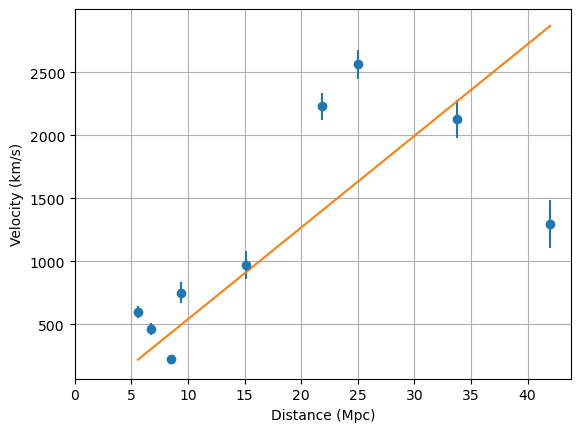

In [33]:
from matplotlib.pyplot import figure, show

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.errorbar(d, v, yerr=ev, marker='o', ls='')
dmin = d.min(); dmax = d.max()
vmin = model(beta,dmin); vmax = model(beta,dmax)
frame.plot([dmin, dmax], [vmin, vmax])
frame.set_xlabel('Distance (Mpc)')
frame.set_ylabel('Velocity (km/s)')
frame.set_xlim(0,None)
frame.grid()
show()

### The covariance matrix

A least squares fit function should return the *covariance matrix* for inspection of the correlation between the model parameters. Assume a matrix $M$ is returned for a set of model parameters $\beta$. Then
the variance of the parameter $\beta_i$ is given by $M^\beta_{ii}$ and the **covariance between parameters** $\beta_i$ and $\beta_j$ is given by $M^\beta_{ij}$. Standard deviation is the square root of variance, and the correlation coefficient is given by $\rho_{ij} = M^\beta_{ij}/(\sigma_i \sigma_j)$.

Let's inspect the matrix for our fit:

In [34]:
M = fitobj.covar
print("Covariance matrix:\n", M)
print("The standard errors are the square root of the diagonal elements:", M[0,0]**0.5, M[1,1]**0.5)
corr = M[1,0]/(M[0,0]*M[1,1])**0.5
print("The correlation (a number between -1 and 1) between model parameter beta0 and beta1 is:", corr)

Covariance matrix:
 [[1157.96808084  -91.11788441]
 [ -91.11788441    9.68176406]]
The standard errors are the square root of the diagonal elements: 34.028930057194195 3.111553319692033
The correlation (a number between -1 and 1) between model parameter beta0 and beta1 is: -0.8605539176349406


### Scaling the weights

What difference does it make if we scale all the weights:

In [35]:
ev = 7*np.array([190, 44, 113, 150, 83, 105, 47, 23, 110])

beta_start= (0, 70)
fitobj = kmpfit.Fitter(residuals=residuals, data=(d,v,ev))
status = fitobj.fit(params0=beta_start)
print("Was the fit successful?", bool(status))

beta = fitobj.params
dbeta = fitobj.stderr
s = u"Model parameters beta0={} \u00B1 {} and beta1={} \u00B1 {}".format(beta[0], dbeta[0], beta[1], dbeta[1])
print(s)

print("Chi squared, reduced Chi squared:", fitobj.chi2_min, fitobj.rchi2_min)
print("The errors derived from the covariance matrix:", fitobj.xerror)
M = fitobj.covar
corr = M[1,0]/(M[0,0]*M[1,1])**0.5
print("The correlation (a number between -1 and 1) between model parameter a and b is:", corr)

Was the fit successful? True
Model parameters beta0=-186.99617458384373 ± 247.35233643332873 and beta1=72.7055940626026 ± 22.617519349761213
Chi squared, reduced Chi squared: 7.548095879577581 1.0782994113682258
The errors derived from the covariance matrix: [238.2025097   21.78087319]
The correlation (a number between -1 and 1) between model parameter a and b is: -0.8605539180899981


What should you observe? 

* The optimal (fitted) model parameters do not change if we scale the weights with a constant. 
* The standard errors we copied from attribute ``stderr`` also do not change. 
* The value for $\chi^2$ and the reduced $\chi^2$ do change
* Unscaled errors derived from the so called *covariance matrix* do change. 
* Correlation between model parameters does not change

### More about weighting data points

If you examine the residuals function in this program, you will observe
that we use a weight of $1/err_i$ in the residuals function, which is squared by ``kmpfit``,
so in fact the weighting for $\chi^2$ is $1/\sigma_i^2$.
In the first fit examples we did set all the errors to 1.0 and kept the residuals function as simple as possible. This is called *unit weighting* and each data point contributes equally to the fit. The choice of a weight of 1 corresponds to a certain scaling of the minimum value of $\chi^2$.

Our second fit has different weights. Each data point has a different weight in the fit procedure. The smaller the error in the data, the bigger the influence in the fit procedure.
Important is the observation that these weights are often relative.
Then they contain information about the quality of the data but do not necessarily
contain correct information about the real errors on the data points and therefore the fit process 
gives incorrect errors in the parameter estimates. This we did prove when we scaled the errors with a constant.
Then the values in the covariance matrix were scaled so that also errors derived from the covariance matrix were scaled.

This demonstrates that if weights are relative or when unit weighting is
applied, one cannot rely on the covariance errors to represent real
errors on the parameter estimates.


To summarize the weighting schemes:

* *Unweighted or unit weighting*: Set  $w_i=1/\sigma_i^2$ to 1.0
* *Relative weighting*: Set $w_i=1/\sigma_i^2$ but the errors on the parameter estimates in ``kmpfit`` attribute ``xerror`` cannot be used.
* *Statistical weighting*: Set $w_i=1/\sigma_i^2$. The errors on the parameter estimates in ``kmpfit`` attribute ``xerror`` are correct. An important assumption of this method is that the error distribution of the measured data is Gaussian and that the data errors are measured accurately (absolute uncertainties).
* Other weighting schemes like Poisson weighting $w_i=1/y_i$

Below we demonstrate again the difference between an unweighted fit and relative weighting:

In [36]:
ev = []   # I need a list of 3 arrays with weights
ev.append(np.array([1, 1, 1, 1, 1, 1, 1, 1, 1]))
ev.append(np.array([190, 44, 113, 150, 83, 105, 47, 23, 110]))
ev.append(7*np.array([190, 44, 113, 150, 83, 105, 47, 23, 110]))

beta_start = (0, 70)
for i in [0,1,2]:
    fitobj = kmpfit.Fitter(residuals=residuals, data=(d,v,ev[i]))
    status = fitobj.fit(params0=beta_start)

    a, b = fitobj.params
    da, db = fitobj.stderr
    print("")
    s = u"Model parameters a={} \u00B1 {} and b={} \u00B1 {}".format(a, da, b, db)
    print(s)
    print("Chi squared, reduced Chi squared:", fitobj.chi2_min, fitobj.rchi2_min)
    print("The errors derived from the covariance matrix:", fitobj.xerror)
    M = fitobj.covar
    corr = M[1,0]/(M[0,0]*M[1,1])**0.5
    print("The correlation (a number between -1 and 1) between model parameter a and b is:", corr)



Model parameters a=414.71769219487254 ± 413.0744314560506 and b=44.58662808085461 ± 18.531843672064927
Chi squared, reduced Chi squared: 3218837.2278252216 459833.8896893174
The errors derived from the covariance matrix: [0.60915502 0.02732865]
The correlation (a number between -1 and 1) between model parameter a and b is: -0.8369979043965615

Model parameters a=-186.996186110472 ± 247.35233715806837 and b=72.70559489812575 ± 22.617519402584207
Chi squared, reduced Chi squared: 369.8566980993014 52.83667115704306
The errors derived from the covariance matrix: [34.02893006  3.11155332]
The correlation (a number between -1 and 1) between model parameter a and b is: -0.8605539176349406

Model parameters a=-186.99617458384373 ± 247.35233643332873 and b=72.7055940626026 ± 22.617519349761213
Chi squared, reduced Chi squared: 7.548095879577581 1.0782994113682258
The errors derived from the covariance matrix: [238.2025097   21.78087319]
The correlation (a number between -1 and 1) between mode

### Reduced $\chi2$

From the theory of maximum likelihood we find that for a least squares solution
we need to maximize the probability that a measurement $y_i$ with given
$\sigma_i$ is in a small interval $\Delta y_i$ around $y_i$ by minimizing the sum
Chi Squared :

$$\boxed{\chi^2(x, \vec{\beta}) = \sum\limits_{i=0}^n \left( \frac{y_i-f(x, \vec{\beta})}{\sigma_i} \right)^2}$$

$$\chi^2 = \sum\limits_{i=0}^{n} {\left(\frac{\Delta y_i}{\sigma_i}\right)}^2 = \sum\limits_{i=0}^{N-1} \frac{({y_i-f(x_{i}))}^2}{\sigma_i^2}$$

where:

* $N$ is the number of data points and $n=N-1$
* $y_i$ the measured data at $x_i$
* $\sigma_i$ is the standard deviation of measurement $i$
* ``f`` is the model for which we want to find the best-fit parameters.
* $\beta$ vector with the model parameters

The sum is often called Chi Squared because it follows the $\chi^2$ distribution
if we repeat the experiment multiple times to get new measurements and new values for $\chi^2$.
On the Internet you can find various pages where for **linear** models it has been derived that the expectation value of $\chi^2$ is
$\langle \chi^2 \rangle = N - n$
where $n$ is the number of free parameters in the fit. The *reduced* Chi Squared
$\chi_{\nu}^2$ is defined as:

$$\chi^2_{\nu} = \frac{\chi^2}{N - n} = \frac{\chi^2}{\nu}$$

where $\nu = N-n$. Then he
expectation value of the reduced Chi Squared is:

$$\langle \chi^2_{\nu} \rangle = 1$$

Fitting with the objective function we used in our examples is often called
Chi Squared fitting. The value of $\chi^2_{\nu}$ is a measure of
the **goodness of fit** and its value is returned by ``kmpfit`` in a ``Fitter`` object as
attribute ``rchi2_min``. The number of degrees of freedom is stored
in attribute ``dof``

$\chi_{\nu}^2$ follows the chi square statistic. This statistic measures
both the spread of the data and the accuracy of the fit.

* The reduced chi squared $\chi_{\nu}^2$ is a measure of the goodness of fit. Its expectation value is 1.
* A value of $\chi_{\nu}^2 \approx 1$ indicates that there is a match between measurements, best-fit parameters and error variances.
* A large value of $\chi_{\nu}^2$ (e.g. > 1.5) indicates a poor model fit.
* $\chi_{\nu}^2 < 1$ indicates that probably the error variance has been over-estimated.
* $\chi_{\nu}^2 > 1$ indicates that probably the error variance has been under-estimated.

**Conclusion**

If the weights are derived from realistic errors in the data points and model and fit are in agreement, the value of the reduced $\chi^2$ must be around 1. Only then, the values in the covariance matrix can be used to derive 1 $\sigma$ errors on the model parameters and one can use attribute ``xerror``, else the covariance matrix is scaled so that it corresponds with a reduced Chi Squared $\chi_{\nu}^2 = 1$. Then the square root of the diagonal values represent 1 $\sigma$ errors of the model parameters of a 'perfect fit'. In ``kmpfit``, and ``leastsq`` these values are stored in attribute ``stderr``.

**Publishing results**

**If you want to publish your model parameters, you should include the 1** $\sigma$ **errors (standard errors) in these parameters. For unit- or relative weighting, you cannot scale variances with** $\chi_{\nu}^2 = 1$ **because for nonlinear models the expectation value needs not to be equal to 1 as it is with a linear model.** 

### Experimenting with random weights

It is easy to experiment with ``kmpfit``. Usually you define a model, derive data points from that model and add random noise from the Normal distribution. Use the template below to experiment with data, model, weights etc.

Fit status:  mpfit (potential) success: Convergence in chi-square value (1)
Best-fit parameters:       (1.105634322484819, 0.9935319466902157, 0.5215880489718182)
Covariance errors:         [0.07651612 0.0119311  0.02587112]
Standard errors            [0.06409098 0.00999366 0.02167002]
Chi^2 min:                 32.97508347996637
Reduced Chi^2:             0.7015975208503483
Iterations:                3
Number of function calls:  9
Number of free pars.:      3
Degrees of freedom:        47
Number of pegged pars.:    0
Covariance matrix:
 [[ 0.00585472 -0.00089266  0.0013166 ]
 [-0.00089266  0.00014235 -0.00019587]
 [ 0.0013166  -0.00019587  0.00066932]]
Correlation between a and b -0.9778061804234317
Correlation between a and c 0.6650959311965334
Correlation between b and c -0.6345663648429182


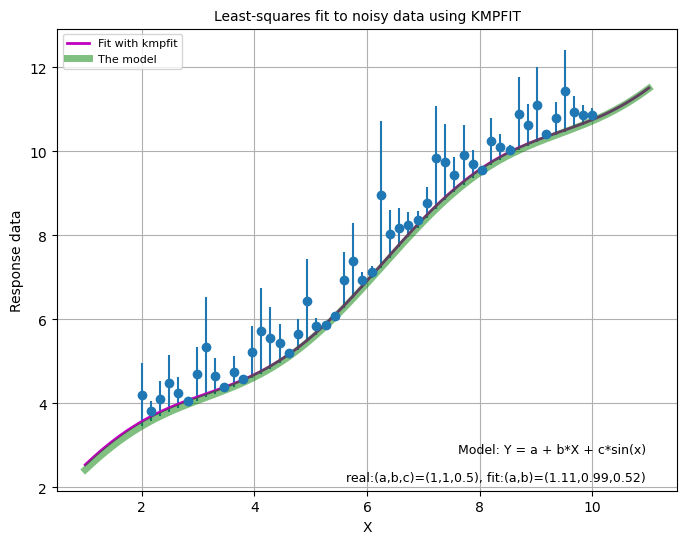

In [37]:
import numpy as np
from matplotlib.pyplot import figure, show, rc
from kapteyn import kmpfit


# The model
#==========
def model(beta, x):
    a,b,c = beta
    y = a + b*x + c*np.sin(x)
    return y


# The residual function
#======================
def residuals(beta, data):
    x, y, err = data                # 'data' is a tuple given by programmer
    return (y - model(beta,x))/err


# Artificial data
#================
N = 50                             # Number of data points
mean = 0.0; sigma = 0.6            # Characteristics of the noise we add
xstart = 2.0; xend = 10.0
x = np.linspace(xstart, xend, N)
paramsreal = [1.0, 1.0, 0.5]
noise = abs(np.random.normal(mean, sigma, N))
y = model(paramsreal, x) + noise


# Prepare a 'Fitter' object'
#===========================
beta_start = (0.8, 0.8, 0.5)
fitobj = kmpfit.Fitter(residuals=residuals, data=(x,y,noise))

try:
    fitobj.fit(params0=beta_start)
except Exception as mes:
    print("Something wrong with fit: ", mes)
    raise SystemExit

print("Fit status: ", fitobj.message)
print("Best-fit parameters:      ", fitobj.params)
print("Covariance errors:        ", fitobj.xerror)
print("Standard errors           ", fitobj.stderr)
print("Chi^2 min:                ", fitobj.chi2_min)
print("Reduced Chi^2:            ", fitobj.rchi2_min)
print("Iterations:               ", fitobj.niter)
print("Number of function calls: ", fitobj.nfev)
print("Number of free pars.:     ", fitobj.nfree)
print("Degrees of freedom:       ", fitobj.dof)
print("Number of pegged pars.:   ", fitobj.npegged)
print("Covariance matrix:\n", fitobj.covar)

M = fitobj.covar
rho01 = M[0,1] /(M[0,0]*M[1,1])**0.5
rho02 = M[0,2] /(M[0,0]*M[2,2])**0.5
rho12 = M[1,2] /(M[1,1]*M[2,2])**0.5
print("Correlation between a and b", rho01)
print("Correlation between a and c", rho02)
print("Correlation between b and c", rho12)

# Plot the result
#================
rc('font', size=10)
rc('legend', fontsize=8)
fig = figure(figsize=(8,6))
xp = np.linspace(xstart-1, xend+1, 200)
frame = fig.add_subplot(1,1,1)
frame.errorbar(x, y, yerr=noise, marker='o', ls='')
frame.plot(xp, model(fitobj.params,xp), 'm', lw=2, label="Fit with kmpfit")
frame.plot(xp, model(paramsreal,xp), 'g', lw=5, alpha=0.5, label="The model")
frame.set_xlabel("X")
frame.set_ylabel("Response data")
frame.set_title("Least-squares fit to noisy data using KMPFIT", fontsize=10)
s = "Model: Y = a + b*X + c*sin(x)"
frame.text(0.95, 0.08, s, color='k', fontsize=9,
           ha='right', transform=frame.transAxes)
s = "real:(a,b,c)=({:.2g},{:.2g},{:.2g}), fit:(a,b)=({:.2f},{:.2f},{:.2f})".format(\
     paramsreal[0],paramsreal[1],paramsreal[2], fitobj.params[0],fitobj.params[1], fitobj.params[2])
frame.text(0.95, 0.02, s, color='k', fontsize=9,
           ha='right', transform=frame.transAxes)
frame.grid(True)
leg = frame.legend(loc=2)
show()

## (OPTIONAL) LMFIT

``lmfit`` is a package for non-linear least squares fitting with more scientific output than other packages.
It can be used to solve the linear regression problem (which is a linear least squares problem) with the Hubble data.

Explore ``lmfit`` on https://lmfit.github.io/lmfit-py/

lmfit parameter names: ['a', 'b']
lmfit independent variable: ['x']
[[Model]]
    Model(linemodel)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 22
    # data points      = 9
    # variables        = 2
    chi-square         = 3218837.23
    reduced chi-square = 459833.890
    Akaike info crit   = 119.085755
    Bayesian info crit = 119.480205
    R-squared          = 0.45263662
[[Variables]]
    a:  414.717695 +/- 413.074430 (99.60%) (init = 0)
    b:  44.5866282 +/- 18.5318439 (41.56%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(a, b) = -0.8370


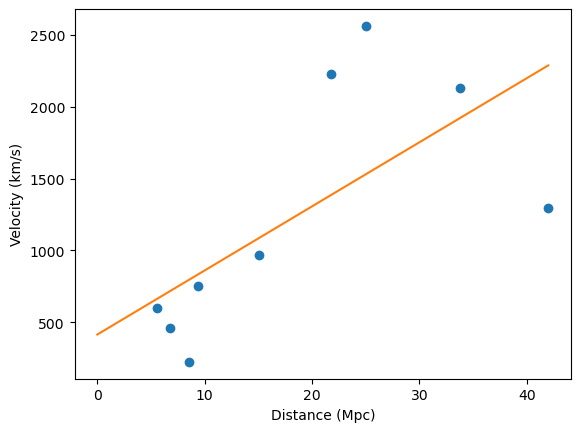

In [38]:
from lmfit import Model
from matplotlib.pyplot import figure, show
d = np.array([42, 6.75, 25, 33.8, 9.36, 21.8, 5.58, 8.52, 15.1])
v = np.array([1294, 462, 2562, 2130, 750, 2228, 598, 224, 971])

def linemodel(x, a, b):
    return a + b*x

gmodel = Model(linemodel)
print("lmfit parameter names:", gmodel.param_names)
print("lmfit independent variable:", gmodel.independent_vars)
params = gmodel.make_params()
result = gmodel.fit(v, params, x=d, a=0, b=0)
print(result.fit_report())

X  = np.linspace(0, d.max(), 100)
Y = result.eval(x=X)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.plot(d, v, marker='o', ls='')
frame.plot(X, Y)

frame.set_xlabel('Distance (Mpc)')
frame.set_ylabel('Velocity (km/s)')
show()